# 🔆 Overview
This notebook imports minute level synthetic data train_onset_final_0329.csv and test_onset_final_0329.csv, builds the CNN model.

Here, we predict the glucose status of current using x minutes data that n-minute ahead of now.

# 🔆 Setup / Import Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from itertools import product
from collections import Counter

# sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight

# tf and keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
# mounting on gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import data
data_path = "/content/drive/MyDrive/210 Capstone/final_data/updated"

In [ ]:
# import train df: canine 2 - 6
file_train_df = os.path.join(data_path, "train_onset_final_0329.csv")
raw_train_df = pd.read_csv(file_train_df)

raw_train_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine2,canine2-001,2025-04-09 12:56:00,308.000000,hyperglycemia,True,True,False,False,train
1,canine2,canine2-001,2025-04-09 12:57:00,305.615730,hyperglycemia,True,False,False,False,train
2,canine2,canine2-001,2025-04-09 12:58:00,303.471173,hyperglycemia,True,False,False,False,train
3,canine2,canine2-001,2025-04-09 12:59:00,301.876377,hyperglycemia,True,False,False,False,train
4,canine2,canine2-001,2025-04-09 13:00:00,298.388740,hyperglycemia,True,False,False,False,train


In [ ]:
# import test df: canine 1
file_test_df = os.path.join(data_path, "test_onset_final_0329.csv")
raw_test_df = pd.read_csv(file_test_df)

raw_test_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,test
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,test
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False,test
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False,test
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False,test


# 🔆 CNN Model
* LODO
* target = glucose_category: hyperglycemia, hypoglycemia and normal
* history 30 mins data to predict 15 mins ahead

## ⭐ Feature Setup

In [ ]:
train_df = raw_train_df.copy()
test_df  = raw_test_df.copy()

train_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine2,canine2-001,2025-04-09 12:56:00,308.000000,hyperglycemia,True,True,False,False,train
1,canine2,canine2-001,2025-04-09 12:57:00,305.615730,hyperglycemia,True,False,False,False,train
2,canine2,canine2-001,2025-04-09 12:58:00,303.471173,hyperglycemia,True,False,False,False,train
3,canine2,canine2-001,2025-04-09 12:59:00,301.876377,hyperglycemia,True,False,False,False,train
4,canine2,canine2-001,2025-04-09 13:00:00,298.388740,hyperglycemia,True,False,False,False,train


In [ ]:
# Feature Setup
feature_cols = ["glucose"]
target_col = "glucose_category"

history_len = 30   # 30 minutes history
ahead_len = 15     # predict 15 minutes ahead

# Encode Target Labels
label_encoder = LabelEncoder()

label_encoder.fit(train_df[target_col])

print("Classes:", list(label_encoder.classes_))

train_df["target_encoded"] = label_encoder.transform(train_df[target_col])
test_df["target_encoded"] = label_encoder.transform(test_df[target_col])

train_df[[target_col, "target_encoded"]].head()

Classes: ['hyperglycemia', 'hypoglycemia', 'normal']


,glucose_category,target_encoded
0,hyperglycemia,0
1,hyperglycemia,0
2,hyperglycemia,0
3,hyperglycemia,0
4,hyperglycemia,0


In [ ]:
# Build sequence windows - turns row-level data into dorecasting samples
# 30 minutes of history, ending 15 minutes before target t

def build_sequences_ahead(
    df,
    feature_cols,
    target_col="target_encoded",
    history_len=30,
    ahead_len=15
):
    """
    For target index i:
      X = rows [i - ahead_len - history_len : i - ahead_len]
      y = row i

    Example:
      history_len = 30
      ahead_len = 15
      -> use [t-45, t-15) to predict target at t
    """
    X_list = []
    y_list = []

    grouped = df.groupby(["dogID", "ID"], sort=False)
    min_required_len = history_len + ahead_len

    for (dog_id, seg_id), g in grouped:
        g = g.sort_values("timestamp").reset_index(drop=True)

        if len(g) <= min_required_len:
            continue

        X_values = g[feature_cols].values
        y_values = g[target_col].values

        for i in range(min_required_len, len(g)):
            start_idx = i - ahead_len - history_len
            end_idx = i - ahead_len

            X_window = X_values[start_idx:end_idx]
            y_target = y_values[i]

            if len(X_window) != history_len:
                continue

            X_list.append(X_window)
            y_list.append(y_target)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)

    return X, y

## ⭐ CNN

In [ ]:
def build_cnn_model(history_len, n_features, n_classes):
  """
  Define the CNN architecture.
  This model learns local patterns in the glucose sequence.
  """
  model = Sequential([
      Conv1D(
          filters=32,
          kernel_size=3,
          activation="relu",
          input_shape=(history_len, n_features)
      ),
      BatchNormalization(),
      MaxPooling1D(pool_size=2),

      Conv1D(
          filters=64,
          kernel_size=3,
          activation="relu"
      ),
      BatchNormalization(),
      GlobalAveragePooling1D(),

      Dense(32, activation="relu"),
      Dropout(0.3),
      Dense(n_classes, activation="softmax")
  ])

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss="categorical_crossentropy",
      metrics=["accuracy"]
  )

  return model

## ⭐ Run LODO

In [ ]:
def run_lodo_cnn(
    train_df,
    feature_cols,
    history_len=30,
    ahead_len=15,
    epochs=15,
    batch_size=32
):
    results = []
    all_y_true = []
    all_y_pred = []

    all_dogs = sorted(train_df["dogID"].unique())
    n_classes = len(label_encoder.classes_)

    for val_dog in all_dogs:
        print("\n" + "=" * 70)
        print(f"LODO fold - validation dog: {val_dog}")
        print("=" * 70)

        # Split by dog
        fold_train_df = train_df[train_df["dogID"] != val_dog].copy()
        fold_val_df = train_df[train_df["dogID"] == val_dog].copy()

        print("fold_train_df:", fold_train_df.shape)
        print("fold_val_df:", fold_val_df.shape)

        # Build sequences
        X_train, y_train = build_sequences_ahead(
            fold_train_df,
            feature_cols=feature_cols,
            target_col="target_encoded",
            history_len=history_len,
            ahead_len=ahead_len
        )

        X_val, y_val = build_sequences_ahead(
            fold_val_df,
            feature_cols=feature_cols,
            target_col="target_encoded",
            history_len=history_len,
            ahead_len=ahead_len
        )

        print("X_train shape:", X_train.shape)
        print("X_val shape:", X_val.shape)


        # One-hot encode labels
        y_train_cat = to_categorical(y_train, num_classes=n_classes)
        y_val_cat = to_categorical(y_val, num_classes=n_classes)

        # Class weights
        classes = np.unique(y_train)
        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train
        )
        class_weight_dict = dict(zip(classes, class_weights))
        print("class_weight_dict:", class_weight_dict)

        # Fresh model for this fold
        tf.keras.backend.clear_session()
        tf.random.set_seed(42)
        np.random.seed(42)

        model = build_cnn_model(
            history_len=history_len,
            n_features=len(feature_cols),
            n_classes=n_classes
        )

        # Train
        model.fit(
            X_train,
            y_train_cat,
            validation_data=(X_val, y_val_cat),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            class_weight=class_weight_dict,
            verbose=0
        )

        # Predict on validation dog
        y_prob = model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        # Metrics
        acc = accuracy_score(y_val, y_pred)
        f1_macro = f1_score(y_val, y_pred, average="macro")
        f1_weighted = f1_score(y_val, y_pred, average="weighted")

        print(f"Accuracy: {acc:.4f}")
        print(f"F1 Macro: {f1_macro:.4f}")
        print(f"F1 Weighted: {f1_weighted:.4f}")

        results.append({
            "val_dog": val_dog,
            "n_train_seq": len(X_train),
            "n_val_seq": len(X_val),
            "accuracy": acc,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted
        })

        all_y_true.extend(y_val.tolist())
        all_y_pred.extend(y_pred.tolist())

    results_df = pd.DataFrame(results)

    print("\nLODO results by fold:")
    print(results_df)

    if len(results_df) > 0:
        print("\nMean metrics:")
        print(results_df[["accuracy", "f1_macro", "f1_weighted"]].mean())

        print("\nOverall classification report:")
        print(classification_report(
            all_y_true,
            all_y_pred,
            target_names=label_encoder.classes_,
            digits=4
        ))

        print("\nOverall confusion matrix:")
        print(confusion_matrix(all_y_true, all_y_pred))

    return results_df

In [ ]:
# Run

lodo_cnn_results_df = run_lodo_cnn(
    train_df=train_df,
    feature_cols=feature_cols,
    history_len=30,
    ahead_len=15,
    epochs=15,
    batch_size=32
)

lodo_cnn_results_df



LODO fold - validation dog: canine2
fold_train_df: (343506, 11)
fold_val_df: (13227, 11)
X_train shape: (331896, 30, 1)
X_val shape: (12867, 30, 1)
class_weight_dict: {np.int32(0): np.float64(0.49590303551897874), np.int32(1): np.float64(150.93042291950886), np.int32(2): np.float64(1.0236973841271015)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.4936
F1 Macro: 0.2228
F1 Weighted: 0.4187

LODO fold - validation dog: canine3
fold_train_df: (294125, 11)
fold_val_df: (62608, 11)
X_train shape: (284225, 30, 1)
X_val shape: (60538, 30, 1)
class_weight_dict: {np.int32(0): np.float64(0.5162499069124541), np.int32(1): np.float64(80.22156364662715), np.int32(2): np.float64(0.9519383739428954)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.7256
F1 Macro: 0.2814
F1 Weighted: 0.6107

LODO fold - validation dog: canine4
fold_train_df: (324452, 11)
fold_val_df: (32281, 11)
X_train shape: (313292, 30, 1)
X_val shape: (31471, 30, 1)
class_weight_dict: {np.int32(0): np.float64(0.47071797969235024), np.int32(1): np.float64(86.09288266007145), np.int32(2): np.float64(1.1574471229334071)}


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8049
F1 Macro: 0.2973
F1 Weighted: 0.7179

LODO fold - validation dog: canine6
fold_train_df: (178387, 11)
fold_val_df: (178346, 11)
X_train shape: (174337, 30, 1)
X_val shape: (170426, 30, 1)
class_weight_dict: {np.int32(0): np.float64(0.5297386812518992), np.int32(1): np.float64(95.42255062944719), np.int32(2): np.float64(0.9076081297765561)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.5704
F1 Macro: 0.3807
F1 Weighted: 0.5632

LODO results by fold:
   val_dog  n_train_seq  n_val_seq  accuracy  f1_macro  f1_weighted
0  canine2       331896      12867  0.493588  0.222783     0.418712
1  canine3       284225      60538  0.725610  0.281424     0.610704
2  canine4       313292      31471  0.000000  0.000000     0.000000
3  canine5       275302      69461  0.804927  0.297307     0.717931
4  canine6       174337     170426  0.570359  0.380707     0.563217

Mean metrics:
accuracy       0.518897
f1_macro       0.236444
f1_weighted    0.462113
dtype: float64

Overall classification report:
               precision    recall  f1-score   support

hyperglycemia     0.8266    0.6387    0.7206    227418
 hypoglycemia     0.0000    0.0000    0.0000      1213
       normal     0.4291    0.5007    0.4622    116132

     accuracy                         0.5900    344763
    macro avg     0.4186    0.3798    0.3942    344763
 weighted avg     0.6898    0.5900    0.6310    3

,val_dog,n_train_seq,n_val_seq,accuracy,f1_macro,f1_weighted
0,canine2,331896,12867,0.493588,0.222783,0.418712
1,canine3,284225,60538,0.725610,0.281424,0.610704
2,canine4,313292,31471,0.000000,0.000000,0.000000
3,canine5,275302,69461,0.804927,0.297307,0.717931
4,canine6,174337,170426,0.570359,0.380707,0.563217


### **Check Class Imbalance**

In [ ]:
def inspect_fold_class_balance(
    train_df,
    val_dog,
    feature_cols,
    history_len,
    ahead_len,
    label_encoder
):
    from collections import Counter

    fold_train_df = train_df[train_df["dogID"] != val_dog].copy()
    fold_val_df = train_df[train_df["dogID"] == val_dog].copy()

    X_train, y_train = build_sequences_ahead(
        fold_train_df,
        feature_cols=feature_cols,
        target_col="target_encoded",
        history_len=history_len,
        ahead_len=ahead_len
    )

    X_val, y_val = build_sequences_ahead(
        fold_val_df,
        feature_cols=feature_cols,
        target_col="target_encoded",
        history_len=history_len,
        ahead_len=ahead_len
    )

    print("=" * 70)
    print(f"Validation dog: {val_dog}")
    print("=" * 70)

    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)
    print()

    print("Encoded train label counts:")
    print(Counter(y_train))
    print()

    print("Encoded val label counts:")
    print(Counter(y_val))
    print()

    train_label_names = label_encoder.inverse_transform(y_train)
    val_label_names = label_encoder.inverse_transform(y_val)

    print("Train sequence class counts:")
    print(pd.Series(train_label_names).value_counts())
    print()

    print("Train sequence class proportions:")
    print(pd.Series(train_label_names).value_counts(normalize=True))
    print()

    print("Validation sequence class counts:")
    print(pd.Series(val_label_names).value_counts())
    print()

    print("Validation sequence class proportions:")
    print(pd.Series(val_label_names).value_counts(normalize=True))
    print()

    classes = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    class_weight_dict = dict(zip(classes, class_weights))

    print("Readable class weights:")
    for cls_id, weight in class_weight_dict.items():
        cls_name = label_encoder.inverse_transform([cls_id])[0]
        print(f"{cls_id} ({cls_name}): {weight:.4f}")

In [ ]:
for dog in sorted(train_df["dogID"].unique()):
    print("\n\n")
    inspect_fold_class_balance(
        train_df=train_df,
        val_dog=dog,
        feature_cols=feature_cols,
        history_len=30,
        ahead_len=15,
        label_encoder=label_encoder
    )




Validation dog: canine2
X_train shape: (331896, 30, 1)
X_val shape: (12867, 30, 1)

Encoded train label counts:
Counter({np.int32(0): 223092, np.int32(2): 108071, np.int32(1): 733})

Encoded val label counts:
Counter({np.int32(2): 8061, np.int32(0): 4326, np.int32(1): 480})

Train sequence class counts:
hyperglycemia    223092
normal           108071
hypoglycemia        733
Name: count, dtype: int64

Train sequence class proportions:
hyperglycemia    0.672174
normal           0.325617
hypoglycemia     0.002209
Name: proportion, dtype: float64

Validation sequence class counts:
normal           8061
hyperglycemia    4326
hypoglycemia      480
Name: count, dtype: int64

Validation sequence class proportions:
normal           0.626486
hyperglycemia    0.336209
hypoglycemia     0.037305
Name: proportion, dtype: float64

Readable class weights:
0 (hyperglycemia): 0.4959
1 (hypoglycemia): 150.9304
2 (normal): 1.0237



Validation dog: canine3
X_train shape: (284225, 30, 1)
X_val shape: (6

## ⭐ Model Test

In [ ]:
# Prepare full training data
X_train_full, y_train_full = build_sequences_ahead(
    train_df,
    feature_cols=feature_cols,
    target_col="target_encoded",
    history_len=history_len,
    ahead_len=ahead_len
)

# Prepare test data
X_test, y_test = build_sequences_ahead(
    test_df,
    feature_cols=feature_cols,
    target_col="target_encoded",
    history_len=history_len,
    ahead_len=ahead_len
)

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_full shape: (344763, 30, 1)
y_train_full shape: (344763,)
X_test shape: (35673, 30, 1)
y_test shape: (35673,)


In [ ]:
# One-hot encode labels for full training and test sets
n_classes = len(label_encoder.classes_)
y_train_full_cat = to_categorical(y_train_full, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

# Compute class weights for the full training set
classes_full = np.unique(y_train_full)
class_weights_full = compute_class_weight(
    class_weight="balanced",
    classes=classes_full,
    y=y_train_full
)
class_weight_dict_full = dict(zip(classes_full, class_weights_full))
print("Class weight dict for full training set:", class_weight_dict_full)

Class weight dict for full training set: {np.int32(0): np.float64(0.5053293934517057), np.int32(1): np.float64(94.74113767518548), np.int32(2): np.float64(0.9895722109323872)}


In [ ]:
# Build and train the final CNN model on the entire training dataset
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

final_model = build_cnn_model(
    history_len=history_len,
    n_features=len(feature_cols),
    n_classes=n_classes
)


print("Training final model...")
final_model.fit(
    X_train_full,
    y_train_full_cat,
    epochs=10,
    batch_size=32,
    shuffle=False,
    #class_weight=class_weight_dict_full,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training final model...
Epoch 1/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.7369 - loss: 0.5666
Epoch 2/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.7343 - loss: 0.5635
Epoch 3/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.7320 - loss: 0.5630
Epoch 4/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.7339 - loss: 0.5632
Epoch 5/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.7335 - loss: 0.5630
Epoch 6/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.7314 - loss: 0.5627
Epoch 7/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.7262 - loss: 0.5694
Epoch 8/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.7252 - loss: 0.5704
Epoch 9/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.7272 - loss: 0.5707
Epoch 10/10
10774/10774 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.7146 - loss: 0.5830
Final model training complete.



Test Set Accuracy: 0.6206
Test Set F1 Macro: 0.2553
Test Set Recall: 0.3333

Test Set Classification Report:
               precision    recall  f1-score   support

hyperglycemia     0.6206    1.0000    0.7659     22137
 hypoglycemia     0.0000    0.0000    0.0000      1367
       normal     0.0000    0.0000    0.0000     12169

     accuracy                         0.6206     35673
    macro avg     0.2069    0.3333    0.2553     35673
 weighted avg     0.3851    0.6206    0.4753     35673


Test Set Confusion Matrix:
[[22137     0     0]
 [ 1367     0     0]
 [12169     0     0]]


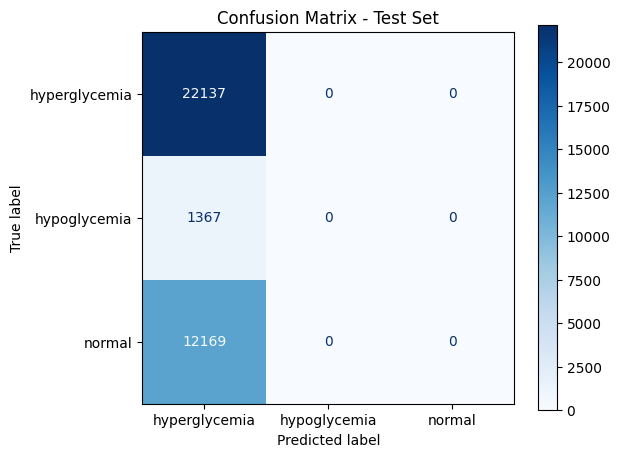

In [ ]:
# Evaluate the final model on the test set
y_prob_test = final_model.predict(X_test, verbose=0)
y_pred_test = np.argmax(y_prob_test, axis=1)

acc_test = accuracy_score(y_test, y_pred_test)
f1_macro_test = f1_score(y_test, y_pred_test, average="macro")
f1_weighted_test = f1_score(y_test, y_pred_test, average="weighted")
recall_test = recall_score(y_test, y_pred_test, average="macro")

print(f"\nTest Set Accuracy: {acc_test:.4f}")
print(f"Test Set F1 Macro: {f1_macro_test:.4f}")
print(f"Test Set Recall: {recall_test:.4f}")

print("\nTest Set Classification Report:")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=label_encoder.classes_,
    digits=4,
    zero_division=0
))

print("\nTest Set Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=label_encoder.classes_
)
fig_test, ax_test = plt.subplots(figsize=(6, 5))
disp_test.plot(ax=ax_test, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.show()